# Research Project 

#### Course: Introduction to Machine Learning and Data Mining 
#### Master in Data Science and Engineering - FEUP

#### Group 7

202206252 - Inês Neves
\
202208293 - Beatriz Moreira 

# Table of Contents
- Required Libraries
- Automated Dataset Retrieval and Conversion
- Data Exploration Pipeline
    - Analysis of the Datasets
    - Pre-Processing Binary Datasets
    - Datasets Analysis
    - Selecting Datasets
- XGBoost for Binary Classification
    - Original Model
    - Altered Model - Gradient Clipping Variant
- Original Model Evaluation Pipeline Across Datasets
- Altered Model Evaluation Pipeline Across Datasets
- Results Overview
- Result Interpretation Plots
    - Original Model Metrics
    - Altered Model Metrics
- Fold-wise Differences Between Original and Altered Models
- Mean Differences Between Original and Altered Models
- Heatmap of Differences
- Additional Research: Synthetic Data Experiments
    - Synthetic Datasets
    - Models Training - Original and Altered
    - Metrics Tables


## Required Libraries

In [1]:
import pandas as pd
import numpy as np
import math
import os
import shutil
import openml
import requests
from scipy.stats import iqr
from collections import defaultdict

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

## Automated Datasets Retrieval and Conversion

In [2]:
cache_dir = os.path.expanduser("~/.openml/org/openml/www/datasets")

for root, dirs, files in os.walk(cache_dir):
    for f in files:
        if f.endswith(".pq") or f.endswith(".parquet"):
            os.remove(os.path.join(root, f))
            print("Deleted:", os.path.join(root, f))

Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\1049\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\1050\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\1053\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\1063\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\1067\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\1068\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\11\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\12\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\14\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\1461\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\1462\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\1464\dataset.pq
Deleted: C:\Users\InesNeves/.openml/org/openml/www/datasets\1468\dataset.pq
Deleted: C:\Users\

In [3]:
suite = openml.study.get_suite(99)

print(type(suite))
print(suite.__dict__.keys())
print(suite)

<class 'openml.study.study.OpenMLBenchmarkSuite'>
dict_keys(['study_id', 'alias', 'main_entity_type', 'benchmark_suite', 'name', 'description', 'status', 'creation_date', 'creator', 'tags', 'data', 'tasks', 'flows', 'setups', 'runs'])
OpenML Benchmark Suite
ID..............: 99
Name............: OpenML-CC18 Curated Classification benchmark
Status..........: active
Main Entity Type: task
Study URL.......: https://www.openml.org/s/99
# of Data.......: 72
# of Tasks......: 72
Creator.........: https://www.openml.org/u/1
Upload Time.....: 2019-02-21 18:47:13


In [4]:
# Configurations
openml.config.cache_format = "arff"
output_folder = "./openml_cc18_csv"
os.makedirs(output_folder, exist_ok=True)


# Clear OpenML dataset cache
cache_dir = os.path.expanduser("~/.openml/org/openml/www/datasets")
if os.path.exists(cache_dir):
    print(f"Deleting OpenML dataset cache at {cache_dir} ...")
    shutil.rmtree(cache_dir)
    print("Cache deleted.")


# Load OpenML-CC18 suite
suite_id = 99
print(f"Loading OpenML Benchmark Suite {suite_id} ...")
suite = openml.study.get_suite(suite_id)
data_ids = suite.data
print(f"Found {len(data_ids)} datasets in the suite.")


# ARFF to CSV converter
def arff_to_csv(lines):
    data_section = False
    header = []
    csv_lines = []

    for line in lines:
        line = line.strip()
        if not line or line.startswith('%'):
            continue
        if not data_section:
            if line.lower().startswith("@attribute"):
                parts = line.split()
                column_name = parts[1].strip()
                header.append(column_name)
            elif line.lower() == "@data":
                data_section = True
                csv_lines.append(",".join(header))
        else:
            csv_lines.append(line)
    return csv_lines


# Download and convert datasets
for did in data_ids:
    try:
        print(f"\nDownloading dataset {did} ...")
        ds = openml.datasets.get_dataset(did)

        # Get ARFF download URL
        url = ds.url
        arff_response = requests.get(url)
        arff_response.raise_for_status()
        arff_lines = arff_response.text.splitlines()

        csv_lines = arff_to_csv(arff_lines)

        filename = f"{ds.name}_v{ds.version}_d{did}.csv"
        csv_path = os.path.join(output_folder, filename)
        with open(csv_path, "w") as f:
            f.write("\n".join(csv_lines))

        print(f"Saved CSV: {csv_path}")

    except Exception as e:
        print(f"Unexpected failure for dataset {did}: {e}")

print("\nAll datasets processed!")

Deleting OpenML dataset cache at C:\Users\InesNeves/.openml/org/openml/www/datasets ...
Cache deleted.
Loading OpenML Benchmark Suite 99 ...
Found 72 datasets in the suite.

Saved CSV: ./openml_cc18_csv\kr-vs-kp_v1_d3.csv

Saved CSV: ./openml_cc18_csv\letter_v1_d6.csv

Saved CSV: ./openml_cc18_csv\balance-scale_v1_d11.csv

Saved CSV: ./openml_cc18_csv\mfeat-factors_v1_d12.csv

Saved CSV: ./openml_cc18_csv\mfeat-fourier_v1_d14.csv

Saved CSV: ./openml_cc18_csv\breast-w_v1_d15.csv

Saved CSV: ./openml_cc18_csv\mfeat-karhunen_v1_d16.csv

Saved CSV: ./openml_cc18_csv\mfeat-morphological_v1_d18.csv

Saved CSV: ./openml_cc18_csv\mfeat-zernike_v1_d22.csv

Saved CSV: ./openml_cc18_csv\cmc_v1_d23.csv

Saved CSV: ./openml_cc18_csv\optdigits_v1_d28.csv

Saved CSV: ./openml_cc18_csv\credit-approval_v1_d29.csv

Saved CSV: ./openml_cc18_csv\credit-g_v1_d31.csv

Saved CSV: ./openml_cc18_csv\pendigits_v1_d32.csv

Saved CSV: ./openml_cc18_csv\diabetes_v1_d37.csv

Saved CSV: ./openml_cc18_csv\spambase_v

## Data Exploration Pipeline

### Analysis of the Datasets

In [2]:
# Determines if the datasets are for Binary or Multi-class Classification
def list_all_datasets(folder_path):

    dataset_list = []
    for filename in os.listdir(folder_path):
        if not filename.endswith(".csv"):
            continue
        file_path = os.path.join(folder_path, filename)

        try:
            df = pd.read_csv(file_path)
            # Assuming target column as the last one
            target_col = df.columns[-1]
            target = df[target_col]
            unique_classes = target.nunique()
            classification_type = "Binary" if unique_classes == 2 else f"Multi-class ({unique_classes})"
            dataset_list.append({
                'Dataset_Name': filename,
                'Samples': len(df),
                'Features': df.shape[1] - 1, # Exclude target
                'Classes': unique_classes,
                'Classification_Type': classification_type
            })
        
        except Exception as e:
            dataset_list.append({
                'Dataset_Name': filename,
                'Classification_Type': f"Error loading: {e}",
                'Samples': 0,
                'Features': 0,
                'Classes': 0
            })
            
    print(f"Total files scanned: {len(os.listdir(folder_path))}")      
    return pd.DataFrame(dataset_list)

In [3]:
folder = "./openml_cc18_csv"

all_datasets_df = list_all_datasets(folder_path=folder)
print(all_datasets_df.to_markdown(index=False))

Total files scanned: 72
| Dataset_Name                                         |   Samples |   Features |   Classes | Classification_Type   |
|:-----------------------------------------------------|----------:|-----------:|----------:|:----------------------|
| adult_v2_d1590.csv                                   |     48842 |         14 |         2 | Binary                |
| analcatdata_authorship_v1_d458.csv                   |       841 |         70 |         4 | Multi-class (4)       |
| analcatdata_dmft_v1_d469.csv                         |       797 |          4 |         6 | Multi-class (6)       |
| balance-scale_v1_d11.csv                             |       625 |          4 |         3 | Multi-class (3)       |
| bank-marketing_v1_d1461.csv                          |     45211 |         16 |         2 | Binary                |
| banknote-authentication_v1_d1462.csv                 |      1372 |          4 |         2 | Binary                |
| Bioresponse_v1_d4134.csv      

### Pre-Processing Binary Datasets

In [4]:
#Filter and load Binary Datasets
def filter_binary_datasets(all_datasets_df, folder_path):

    binary_names = all_datasets_df[
        all_datasets_df['Classification_Type'] == 'Binary'
    ]['Dataset_Name'].tolist()

    binary_datasets = []

    for filename in binary_names:
        file_path = os.path.join(folder_path, filename)

        try:
            # Load CSV
            df = pd.read_csv(file_path)

            # Encode categorical columns
            for col in df.columns:
                if df[col].dtype == 'object' or str(df[col].dtype) == 'category':
                    df[col] = df[col].astype('category').cat.codes
            
            # Define target column (last column)
            target_col = df.columns[-1]
            target = df[target_col]

            # Normalize target to {0, 1}
            unique_labels = sorted(target.unique())
            class_mapping = {unique_labels[0]: 0, unique_labels[1]: 1} 
            df[target_col] = df[target_col].map(class_mapping)

            # Store dataset
            binary_datasets.append({
                'name': filename.replace('.csv', ''),
                'dataframe': df,
                'target_col': target_col
            })
        
        except Exception as e:
            print(f"Skipping {filename} due to structure error during loading: {e}")
            continue

    print(f"Total number of datasets: {len(all_datasets_df)}. Binary datasets selected and loaded: {len(binary_datasets)}")
    return binary_datasets

In [5]:
binary_datasets_list = filter_binary_datasets(all_datasets_df, folder_path=folder)

Total number of datasets: 72. Binary datasets selected and loaded: 35


### Datasets Analysis

In [6]:
# Analyzes each binary dataset for outliers, imbalance, and qualitative attributes.
def analyze_dataset_characteristics(binary_datasets, iqr_factor=1.5, max_categories=10):
    """
    Args:
        binary_datasets (list): List of dictionaries returned by filter_binary_datasets.
        iqr_factor (float):  Factor for calculating outliers (1.5 is the default).
        max_categories (int):  Threshold for defining a ‘large number’ of values for qualitative attributes.
        
    Returns:
        pd.DataFrame: A summary of the characteristics of each dataset.
    """
    analysis_results = []
    
    for item in binary_datasets:
        df = item['dataframe']
        filename = item['name']
        target_col = item['target_col']
        X = df.drop(columns=[target_col])
        y = df[target_col]

        # Missing Values Percentage
        total_cells = X.size
        missing_cells = X.isnull().sum().sum()
        missing_value_percentage = (missing_cells / total_cells) * 100 if total_cells > 0 else 0
        
        # Outliers and Noise (numerical columns)
        total_outliers = 0
        total_data_points = 0
        X_numeric = X.select_dtypes(include=np.number)
        
        for col in X_numeric.columns:
            data = X_numeric[col].dropna() 
            if len(data) < 4: continue     #requires at least 4 data points (for Q1/Q3 calculation)
                
            Q1 = data.quantile(0.25)
            Q3 = data.quantile(0.75)
            IQR = Q3 - Q1
            
            lower_bound = Q1 - iqr_factor * IQR
            upper_bound = Q3 + iqr_factor * IQR
            
            outlier_count = ((data < lower_bound) | (data > upper_bound)).sum()
            total_outliers += outlier_count
            total_data_points += len(data)

        outlier_percentage = (total_outliers / total_data_points) * 100 if total_data_points > 0 else 0
        
        # Class Imbalance Ratio
        class_counts = y.value_counts()
        minority_class_size = class_counts.min()
        majority_class_size = class_counts.max()
        imbalance_ratio = minority_class_size / majority_class_size
        
        # High Cardinality Qualitative Attributes
        X_qualitative = X.select_dtypes(include=['object', 'category'])
        high_cardinality_features = 0
        
        if not X_qualitative.empty:
            for col in X_qualitative.columns:
                if X_qualitative[col].nunique() > max_categories:
                    high_cardinality_features += 1

        # Class Overlap (Metric: Inverse Mean Separability)
        mean_separability = []
        df_numeric = pd.concat([X_numeric, y], axis=1).dropna() 
        avg_separability = 0.0
        
        if not df_numeric.empty and df_numeric[target_col].nunique() == 2:
            
            class_0 = df_numeric[df_numeric[target_col] == 0].drop(columns=[target_col])
            class_1 = df_numeric[df_numeric[target_col] == 1].drop(columns=[target_col])
            
            for col in class_0.columns:
                mu0, sigma0 = class_0[col].mean(), class_0[col].std()
                mu1, sigma1 = class_1[col].mean(), class_1[col].std()
                
                denominator = sigma0 + sigma1
                
                if denominator > 1e-9:      # Avoing division by zero
                    separability = np.abs(mu1 - mu0) / denominator
                    mean_separability.append(separability)
            
            avg_separability = np.mean(mean_separability) if mean_separability else 0.0
            
        # Overlap Metric --> Inverse of Separability
        overlap_metric = 1 / avg_separability if avg_separability > 1e-6 else 1000.0

        # Results
        analysis_results.append({
            'Dataset_Name': filename,
            'Samples': len(df),
            'Features': X.shape[1],
            'Numerical_Features': X_numeric.shape[1],
            'Qualitative_Features': X_qualitative.shape[1],
            'Missing_Value_Percent': missing_value_percentage,
            'Outlier_Percent': outlier_percentage,
            'Imbalance_Ratio': imbalance_ratio,
            'High_Card_Features': high_cardinality_features,
            'Overlap_Metric': overlap_metric
        })
        
    # Sort the results by Outlier_Percent
    return pd.DataFrame(analysis_results).sort_values(by='Outlier_Percent', ascending=False).reset_index(drop=True)

In [7]:
analysis_df = analyze_dataset_characteristics(binary_datasets_list)
print(analysis_df.to_markdown(index=False, floatfmt=".2f"))

| Dataset_Name                               |   Samples |   Features |   Numerical_Features |   Qualitative_Features |   Missing_Value_Percent |   Outlier_Percent |   Imbalance_Ratio |   High_Card_Features |   Overlap_Metric |
|:-------------------------------------------|----------:|-----------:|---------------------:|-----------------------:|------------------------:|------------------:|------------------:|---------------------:|-----------------:|
| spambase_v1_d44                            |      4601 |         57 |                   57 |                      0 |                    0.00 |             11.71 |              0.65 |                    0 |             5.11 |
| kc1_v1_d1067                               |      2109 |         21 |                   21 |                      0 |                    0.00 |              9.86 |              0.18 |                    0 |             2.67 |
| nomao_v1_d1486                             |     34465 |        118 |                 

### Selecting Datasets

In [8]:
# Selected Datasets with Outlier_Percent > 0.5
datasets_for_experiment = analysis_df[analysis_df['Outlier_Percent'] > 0.5]
print("\nSelected Datasets for XGBoost Experiment:")
print(datasets_for_experiment[['Dataset_Name', 'Outlier_Percent', 'Imbalance_Ratio', 'Overlap_Metric']].to_markdown(index=False, floatfmt=".2f"))


Selected Datasets for XGBoost Experiment:
| Dataset_Name                              |   Outlier_Percent |   Imbalance_Ratio |   Overlap_Metric |
|:------------------------------------------|------------------:|------------------:|-----------------:|
| spambase_v1_d44                           |             11.71 |              0.65 |             5.11 |
| kc1_v1_d1067                              |              9.86 |              0.18 |             2.67 |
| nomao_v1_d1486                            |              9.70 |              0.40 |             3.83 |
| pc1_v1_d1068                              |              9.34 |              0.07 |             3.99 |
| ilpd_v1_d1480                             |              9.14 |              0.40 |             4.53 |
| PhishingWebsites_v1_d4534                 |              8.75 |              0.80 |             5.64 |
| kc2_v1_d1063                              |              8.59 |              0.26 |             2.38 |
| adult_v2_d

The **data characteristic** chosen to address in this project was **noise and outliers**. This decision was based on their substantial impact on gradient-boosted models in **binary classification**, where anomalous samples can distort gradient calculations and compromise model stability. 

Given that the implementation includes both standard XGBoost and a gradient-clipping variant, focusing on noise and outliers provides a relevant and justified basis for assessing the robustness and effectiveness of the proposed approach.

## XGBoost for Binary Classification

***Sources:***

Code from: https://randomrealizations.com/posts/xgboost-from-scratch
\
Paper used: https://arxiv.org/pdf/1603.02754

*Note:* XGBoost Model for Classification was adapted from the previous.

In [9]:
# Logistic Objective
class BinaryLogisticObjective:
    def _sigmoid(self, x): return 1 / (1 + np.exp(-x))

    def gradient(self, y, y_pred):
        p = self._sigmoid(y_pred)
        return p - y

    def hessian(self, y, y_pred):
        p = self._sigmoid(y_pred)
        return p * (1 - p)

    def loss(self, y, y_pred):
        p = self._sigmoid(y_pred)
        eps = 1e-12
        return -np.mean(
            y * np.log(p + eps) +
            (1 - y) * np.log(1 - p + eps))

### Original Model: XGBoost

XGBoost operates by constructing an **ensemble of decision trees** using second-order gradient boosting, making use of both the gradients and hessians of the loss function to guide the optimisation process.

At each boosting iteration, the algorithm fits a new tree to the current residuals and evaluates candidate splits through XGBoost’s regularised gain function, which balances improvements in model fit with structural penalties (λ and γ) to control model complexity.

Leaf weights are computed using a closed-form solution that incorporates L2 regularisation, enhancing numerical stability and reducing overfitting. Hyperparameters such as max_depth, min_child_weight, and subsample provide further control over the depth, robustness, and variance of the model.

The original implementation follows these core principles closely, reflecting a solid understanding of how XGBoost optimises, regularises, and incrementally builds its ensemble.

In [10]:
class TreeBooster:
    def __init__(self, X, g, h, params, max_depth, idxs=None):
        self.params = params
        self.max_depth = max_depth
        assert self.max_depth >= 0, "max_depth must be nonnegative"
        self.min_child_weight = params["min_child_weight"] if params["min_child_weight"] else 1.0
        self.reg_lambda = params["reg_lambda"] if params["reg_lambda"] else 1.0
        self.gamma = params["gamma"] if params["gamma"] else 0.0
        self.colsample_bynode = params["colsample_bynode"] if params["colsample_bynode"] else 1.0
        if isinstance(g, pd.Series): g = g.values
        if isinstance(h, pd.Series): h = h.values
        if idxs is None: idxs = np.arange(len(g))
        self.X, self.g, self.h, self.idxs = X, g, h, idxs
        self.n, self.c = len(idxs), X.shape[1]
        self.value = -g[idxs].sum() / (h[idxs].sum() + self.reg_lambda)
        self.best_score_so_far = 0.0
        if self.max_depth > 0:
            self._maybe_insert_child_nodes()


    def _maybe_insert_child_nodes(self):
        for i in range(self.c): self._find_better_split(i)
        if self.is_leaf: return
        x = self.X.values[self.idxs, self.split_feature_idx]
        left_idx = np.nonzero(x <= self.threshold)[0]
        right_idx = np.nonzero(x > self.threshold)[0]
        self.left = TreeBooster(self.X, self.g, self.h, self.params,
                                self.max_depth - 1, self.idxs[left_idx])
        self.right = TreeBooster(self.X, self.g, self.h, self.params,
                                 self.max_depth - 1, self.idxs[right_idx])
    @property
    def is_leaf(self):
        return self.best_score_so_far == 0.0

    def _find_better_split(self, feature_idx):
        x = self.X.values[self.idxs, feature_idx]
        g, h = self.g[self.idxs], self.h[self.idxs] 
        sort_idx = np.argsort(x)
        sort_g, sort_h, sort_x = g[sort_idx], h[sort_idx], x[sort_idx]
        sum_g, sum_h = g.sum(), h.sum()
        sum_g_right, sum_h_right = sum_g, sum_h
        sum_g_left, sum_h_left = 0., 0.

        for i in range(0, self.n - 1):
            g_i, h_i, x_i, x_i_next = sort_g[i], sort_h[i], sort_x[i], sort_x[i + 1]
            sum_g_left += g_i; sum_g_right -= g_i
            sum_h_left += h_i; sum_h_right -= h_i
            if sum_h_left < self.min_child_weight or x_i == x_i_next:continue
            if sum_h_right < self.min_child_weight: break
            gain = (
                0.5 *
                ((sum_g_left ** 2) / (sum_h_left + self.reg_lambda)
                 + (sum_g_right ** 2) / (sum_h_right + self.reg_lambda)
                 - (sum_g ** 2) / (sum_h + self.reg_lambda))
                - self.gamma / 2)
            if gain > self.best_score_so_far:
                self.best_score_so_far = gain
                self.split_feature_idx = feature_idx
                self.threshold = (x_i + x_i_next) / 2

    def predict(self, X):
        return np.array([self._predict_row(row) for _, row in X.iterrows()])

    def _predict_row(self, row):
        if self.is_leaf:
            return self.value
        if row[self.split_feature_idx] <= self.threshold:
            return self.left._predict_row(row)
        else:
            return self.right._predict_row(row)

In [11]:
class XGBoostModel:
    def __init__(self, params, random_seed=None):
        self.params = defaultdict(lambda: None, params)
        self.subsample = self.params["subsample"] if self.params["subsample"] else 1.0
        self.learning_rate = self.params["learning_rate"] if self.params["learning_rate"] else 0.3
        self.base_prediction = self.params["base_score"] if self.params["base_score"] else 0.0
        self.max_depth = self.params["max_depth"] if self.params["max_depth"] else 5
        self.rng = np.random.default_rng(seed=random_seed)

    def fit(self, X, y, objective, num_boost_round, verbose=False):
        current_predictions = self.base_prediction * np.ones_like(y, dtype=float)
        self.boosters = []
        for i in range(num_boost_round):
            gradients = objective.gradient(y, current_predictions)
            hessians = objective.hessian(y, current_predictions)
            sample_idxs = None if self.subsample == 1.0 else self.rng.choice(
                len(y), size=math.floor(self.subsample * len(y)), replace=False)
            booster = TreeBooster(X, gradients, hessians,
                                  self.params, self.max_depth, sample_idxs)
            current_predictions += self.learning_rate * booster.predict(X)
            self.boosters.append(booster)
            if verbose:
                print(f"[{i}] loss = {objective.loss(y, current_predictions):.5f}")

    def predict(self, X):
        return (
            self.base_prediction + self.learning_rate 
            * np.sum([booster.predict(X) for booster in self.boosters], axis=0)
        )

    def predict_proba(self, X):
        logits = self.predict(X)
        return 1 / (1 + np.exp(-logits))

    def predict_class(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

### Altered Model - XGBoost Gradient Clipping Variant

Inspired by the work of *Qian et al. (2021)*, who examined the role of gradient clipping in stabilizing convergence for incremental gradient methods, we adapt a similar concept to the gradient boosting framework. 

In tree-based boosting, each training instance contributes to the gradient statistics used to compute split gains and leaf values. To investigate whether robustness can be improved, we introduce **per-sample gradient clipping** during the computation of these statistics.

The **goal** of this modification is to limit the influence of extreme residuals — particularly those arising from outliers — while leaving the fundamental boosting procedure unchanged. By constraining unusually large gradients, the variant seeks to reduce sensitivity to extreme feature values and promote more stable updates. 

This adaptation transfers the theoretical motivation of gradient clipping into the context of boosted decision trees, enabling us to experimentally assess whether such a mechanism can enhance robustness without compromising model behaviour.

***Source Paper:*** https://proceedings.mlr.press/v130/qian21a.html

In [12]:
class TreeBooster_Alt:
    def __init__(self, X, g, h, params, max_depth, idxs=None):
        self.params = params
        self.max_depth = max_depth
        assert self.max_depth >= 0, "max_depth must be nonnegative"
        self.min_child_weight = params["min_child_weight"] if params["min_child_weight"] else 1.0
        self.reg_lambda = params["reg_lambda"] if params["reg_lambda"] else 1.0
        self.gamma = params["gamma"] if params["gamma"] else 0.0
        self.colsample_bynode = params["colsample_bynode"] if params["colsample_bynode"] else 1.0
        
        self.grad_clip = params.get("grad_clip", None)
        
        if isinstance(g, pd.Series): g = g.values
        if isinstance(h, pd.Series): h = h.values
        if idxs is None: idxs = np.arange(len(g))
        self.X, self.g, self.h, self.idxs = X, g, h, idxs
        self.n, self.c = len(idxs), X.shape[1]

        if self.grad_clip is not None:
            g_leaf = np.clip(self.g[self.idxs], -self.grad_clip, self.grad_clip)
        else:
            g_leaf = self.g[self.idxs]

        self.value = -g_leaf.sum() / (self.h[self.idxs].sum() + self.reg_lambda)
        self.best_score_so_far = 0.0
        if self.max_depth > 0:
            self._maybe_insert_child_nodes()


    def _maybe_insert_child_nodes(self):
        for i in range(self.c): self._find_better_split(i)
        if self.is_leaf: return
        x = self.X.values[self.idxs, self.split_feature_idx]
        left_idx = np.nonzero(x <= self.threshold)[0]
        right_idx = np.nonzero(x > self.threshold)[0]
        self.left = TreeBooster(self.X, self.g, self.h, self.params,
                                self.max_depth - 1, self.idxs[left_idx])
        self.right = TreeBooster(self.X, self.g, self.h, self.params,
                                 self.max_depth - 1, self.idxs[right_idx])
    @property
    def is_leaf(self):
        return self.best_score_so_far == 0.0

    def _find_better_split(self, feature_idx):
        x = self.X.values[self.idxs, feature_idx]
        g, h = self.g[self.idxs], self.h[self.idxs] 
        sort_idx = np.argsort(x)
        sort_g, sort_h, sort_x = g[sort_idx], h[sort_idx], x[sort_idx]
        sum_g, sum_h = g.sum(), h.sum()
        sum_g_right, sum_h_right = sum_g, sum_h
        sum_g_left, sum_h_left = 0., 0.

        for i in range(0, self.n - 1):
            g_i, h_i, x_i, x_i_next = sort_g[i], sort_h[i], sort_x[i], sort_x[i + 1]
            
            if self.grad_clip is not None:
                g_i_clipped = np.clip(g_i, -self.grad_clip, self.grad_clip)
            else:
                g_i_clipped = g_i

            sum_g_left += g_i_clipped; sum_g_right -= g_i_clipped
            sum_h_left += h_i; sum_h_right -= h_i
            
            
            if sum_h_left < self.min_child_weight or x_i == x_i_next:continue
            if sum_h_right < self.min_child_weight: break
            gain = (
                0.5 *
                ((sum_g_left ** 2) / (sum_h_left + self.reg_lambda)
                 + (sum_g_right ** 2) / (sum_h_right + self.reg_lambda)
                 - (sum_g ** 2) / (sum_h + self.reg_lambda))
                - self.gamma / 2)
            if gain > self.best_score_so_far:
                self.best_score_so_far = gain
                self.split_feature_idx = feature_idx
                self.threshold = (x_i + x_i_next) / 2

    def predict(self, X):
        return np.array([self._predict_row(row) for _, row in X.iterrows()])

    def _predict_row(self, row):
        if self.is_leaf:
            return self.value
        if row[self.split_feature_idx] <= self.threshold:
            return self.left._predict_row(row)
        else:
            return self.right._predict_row(row)

In [13]:
class XGBoostModel_Alt:
    def __init__(self, params, random_seed=None):
        self.params = defaultdict(lambda: None, params)
        self.subsample = self.params["subsample"] if self.params["subsample"] else 1.0
        self.learning_rate = self.params["learning_rate"] if self.params["learning_rate"] else 0.3
        self.base_prediction = self.params["base_score"] if self.params["base_score"] else 0.0
        self.max_depth = self.params["max_depth"] if self.params["max_depth"] else 5
        self.rng = np.random.default_rng(seed=random_seed)

    def fit(self, X, y, objective, num_boost_round, verbose=False):
        current_predictions = self.base_prediction * np.ones_like(y, dtype=float)
        self.boosters = []
        for i in range(num_boost_round):
            gradients = objective.gradient(y, current_predictions)
            hessians = objective.hessian(y, current_predictions)
            sample_idxs = None if self.subsample == 1.0 else self.rng.choice(
                len(y), size=math.floor(self.subsample * len(y)), replace=False)
            booster = TreeBooster_Alt(X, gradients, hessians,
                                  self.params, self.max_depth, sample_idxs)
            current_predictions += self.learning_rate * booster.predict(X)
            self.boosters.append(booster)
            if verbose:
                print(f"[{i}] loss = {objective.loss(y, current_predictions):.5f}")

    def predict(self, X):
        return (
            self.base_prediction + self.learning_rate 
            * np.sum([booster.predict(X) for booster in self.boosters], axis=0)
        )

    def predict_proba(self, X):
        logits = self.predict(X)
        return 1 / (1 + np.exp(-logits))

    def predict_class(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

## Original Model Evaluation Pipeline Across Datasets

In [14]:
# Parameters 
params = {
    "learning_rate": 0.1,
    "max_depth": 5,
    "subsample": 1.0,
    "reg_lambda": 1.0,
    "gamma": 0.0
}

num_boost_round= 100

In [ ]:
# Selected Datasets
exclude = ["adult_v2_d1590", "bank-marketing_v1_d1461", "Bioresponse_v1_d4134", "Internet-Advertisements_v2_d40978", "nomao_v1_d1486", "electricity_v1_d151", "madelon_v1_d1485"]

selected_names = datasets_for_experiment['Dataset_Name'].tolist()
selected_datasets = [
    d for d in binary_datasets_list
    if d['name'] in [name.replace('.csv','') for name in selected_names]
    and d['name'] not in exclude

]

In [16]:
output_dir = "original"
os.makedirs(output_dir, exist_ok=True)

In [17]:
# Training and evaluating each dataset 
results = []
k = 5

for dataset in selected_datasets:
    print(f"Training {dataset['name']}...")
    
    df = dataset['dataframe']
    target_col = dataset['target_col']
    X = df.drop(columns=[target_col])
    y = df[target_col]

    fold_metrics = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "AUC": []
    }

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)


    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"  Fold {fold+1}/{k}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Train model on this fold
        model = XGBoostModel(params)
        model.fit(X_train, y_train, BinaryLogisticObjective(), num_boost_round)

        # Predictions
        preds = model.predict_class(X_test)
        probs = model.predict_proba(X_test)

        # Compute metrics
        fold_metrics["Accuracy"].append(accuracy_score(y_test, preds))
        fold_metrics["Precision"].append(precision_score(y_test, preds))
        fold_metrics["Recall"].append(recall_score(y_test, preds))
        fold_metrics["F1"].append(f1_score(y_test, preds))
        fold_metrics["AUC"].append(roc_auc_score(y_test, probs))


    # Convert to DataFrame after all folders are processed
    df_fold = pd.DataFrame(fold_metrics)

    # Save CSV: one file per dataset
    output_path = os.path.join(output_dir, f"results_{dataset['name']}.csv")
    df_fold.to_csv(output_path, index=False)

    # Average metrics for this dataset
    results.append({
        "Dataset": dataset['name'],
        "Accuracy": np.mean(fold_metrics["Accuracy"]),
        "Precision": np.mean(fold_metrics["Precision"]),
        "Recall": np.mean(fold_metrics["Recall"]),
        "F1": np.mean(fold_metrics["F1"]),
        "AUC": np.mean(fold_metrics["AUC"])
    })

# Results
results_df = pd.DataFrame(results)
results_df.to_csv("original_xgboost_results.csv", index=False)
print("\nFinal Results:")
print(results_df.to_markdown(index=False, floatfmt=".3f"))

Training banknote-authentication_v1_d1462...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training blood-transfusion-service-center_v1_d1464...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training breast-w_v1_d15...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training churn_v1_d40701...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training credit-approval_v1_d29...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training credit-g_v1_d31...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training cylinder-bands_v2_d6332...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training diabetes_v1_d37...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training dresses-sales_v2_d23381...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training ilpd_v1_d1480...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training jm1_v1_d1053...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training kc1_v1_d1067...
 

## Altered Model Evaluation Pipeline Across Datasets

In [18]:
# Parameters 
params = {
    "learning_rate": 0.1,
    "max_depth": 5,
    "subsample": 1.0,
    "reg_lambda": 1.0,
    "gamma": 0.0,
    "grad_clip": 0.5
}

num_boost_round = 100

In [ ]:
# Selected Datasets
exclude = ["adult_v2_d1590", "bank-marketing_v1_d1461", "Bioresponse_v1_d4134", "Internet-Advertisements_v2_d40978", "nomao_v1_d1486", "electricity_v1_d151", "madelon_v1_d1485"]

selected_names = datasets_for_experiment['Dataset_Name'].tolist()
selected_datasets = [
    d for d in binary_datasets_list
    if d['name'] in [name.replace('.csv','') for name in selected_names]
    and d['name'] not in exclude

]

In [20]:
output_dir = "altered"
os.makedirs(output_dir, exist_ok=True)

In [21]:
# Training and evaluating each dataset 
results_alt = []
k=5

for dataset in selected_datasets:
    print(f"Training {dataset['name']}...")
    
    df = dataset['dataframe']
    target_col = dataset['target_col']
    X = df.drop(columns=[target_col])
    y = df[target_col]

    
    fold_metrics_alt = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "AUC": []
    }

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    
    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"  Fold {fold+1}/{k}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # XGBoost Training
        model = XGBoostModel_Alt(params)
        model.fit(X_train, y_train, BinaryLogisticObjective(), num_boost_round)

        # Predictions
        preds = model.predict_class(X_test)
        probs = model.predict_proba(X_test)

        # Compute metrics
        fold_metrics_alt["Accuracy"].append(accuracy_score(y_test, preds))
        fold_metrics_alt["Precision"].append(precision_score(y_test, preds))
        fold_metrics_alt["Recall"].append(recall_score(y_test, preds))
        fold_metrics_alt["F1"].append(f1_score(y_test, preds))
        fold_metrics_alt["AUC"].append(roc_auc_score(y_test, probs))
    

    # Convert to DataFrame after all folders are processed
    df_fold_alt = pd.DataFrame(fold_metrics_alt)

    # Save CSV: one file per dataset
    output_path = os.path.join(output_dir, f"results_{dataset['name']}.csv")
    df_fold_alt.to_csv(output_path, index=False)

    # Metrics
    results_alt.append({
        "Dataset": dataset['name'],
        "Accuracy": np.mean(fold_metrics_alt["Accuracy"]),
        "Precision": np.mean(fold_metrics_alt["Precision"]),
        "Recall": np.mean(fold_metrics_alt["Recall"]),
        "F1": np.mean(fold_metrics_alt["F1"]),
        "AUC": np.mean(fold_metrics_alt["AUC"])
    })

# Results
results_alt_df = pd.DataFrame(results_alt)
results_alt_df.to_csv("altered_xgboost_results.csv", index=False)
print("\nFinal Results:")
print(results_alt_df.to_markdown(index=False, floatfmt=".3f"))

Training banknote-authentication_v1_d1462...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training blood-transfusion-service-center_v1_d1464...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training breast-w_v1_d15...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training churn_v1_d40701...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training credit-approval_v1_d29...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training credit-g_v1_d31...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training cylinder-bands_v2_d6332...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training diabetes_v1_d37...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training dresses-sales_v2_d23381...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training ilpd_v1_d1480...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training jm1_v1_d1053...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training kc1_v1_d1067...
 

## Results Overview

In [22]:
def load_metrics(folder_path):
    """
    Iterates over all CSV files in a folder and extracts:
    Accuracy, Precision, Recall, F1, AUC from each row.
    
    Returns:
        metrics_dict = {
            "Accuracy": [...],
            "Precision": [...],
            "Recall": [...],
            "F1": [...],
            "AUC": [...]
        }
    """
    
    metrics_dict = {
        "Dataset": [],
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "AUC": []
    }
    
    # Iterate over all files in the folder
    for filename in os.listdir(folder_path):
        if filename.endswith(".csv"):
            file_path = os.path.join(folder_path, filename)
            
            # Read the file
            df = pd.read_csv(file_path)

            # Remove prefix "results_"
            clean_name = filename
            clean_name = clean_name.replace("results_", "", 1)
            clean_name = clean_name.replace(".csv", "")

            
            # Append values (all rows)
            metrics_dict["Dataset"].extend([clean_name] * len(df))
            metrics_dict["Accuracy"].extend(df["Accuracy"].tolist())
            metrics_dict["Precision"].extend(df["Precision"].tolist())
            metrics_dict["Recall"].extend(df["Recall"].tolist())
            metrics_dict["F1"].extend(df["F1"].tolist())
            metrics_dict["AUC"].extend(df["AUC"].tolist())
    
    return pd.DataFrame(metrics_dict)

In [23]:
folder = "original"
metrics_original = load_metrics(folder)
metrics_original

,Dataset,Accuracy,Precision,Recall,F1,AUC
0,banknote-authentication_v1_d1462,0.989091,1.000000,0.975410,0.987552,1.000000
1,banknote-authentication_v1_d1462,0.996364,0.991870,1.000000,0.995918,1.000000
2,banknote-authentication_v1_d1462,0.992701,1.000000,0.983607,0.991736,1.000000
3,banknote-authentication_v1_d1462,0.989051,0.976000,1.000000,0.987854,0.999676
4,banknote-authentication_v1_d1462,0.996350,1.000000,0.991803,0.995885,0.999946
...,...,...,...,...,...,...
120,wilt_v2_d40983,0.981405,0.888889,0.754717,0.816327,0.990803
121,wilt_v2_d40983,0.985537,0.913043,0.807692,0.857143,0.982449
122,wilt_v2_d40983,0.985537,0.913043,0.807692,0.857143,0.986144
123,wilt_v2_d40983,0.980372,0.851064,0.769231,0.808081,0.993492


In [24]:
folder = "altered"
metrics_altered = load_metrics(folder)
metrics_altered

,Dataset,Accuracy,Precision,Recall,F1,AUC
0,banknote-authentication_v1_d1462,0.989091,1.000000,0.975410,0.987552,1.000000
1,banknote-authentication_v1_d1462,0.996364,0.991870,1.000000,0.995918,0.999893
2,banknote-authentication_v1_d1462,0.992701,1.000000,0.983607,0.991736,1.000000
3,banknote-authentication_v1_d1462,0.989051,0.976000,1.000000,0.987854,0.999623
4,banknote-authentication_v1_d1462,0.996350,1.000000,0.991803,0.995885,1.000000
...,...,...,...,...,...,...
120,wilt_v2_d40983,0.981405,0.888889,0.754717,0.816327,0.991772
121,wilt_v2_d40983,0.984504,0.877551,0.826923,0.851485,0.980507
122,wilt_v2_d40983,0.984504,0.911111,0.788462,0.845361,0.989398
123,wilt_v2_d40983,0.984504,0.877551,0.826923,0.851485,0.993576


## Result Interpretation Plots

### Original Model Metrics

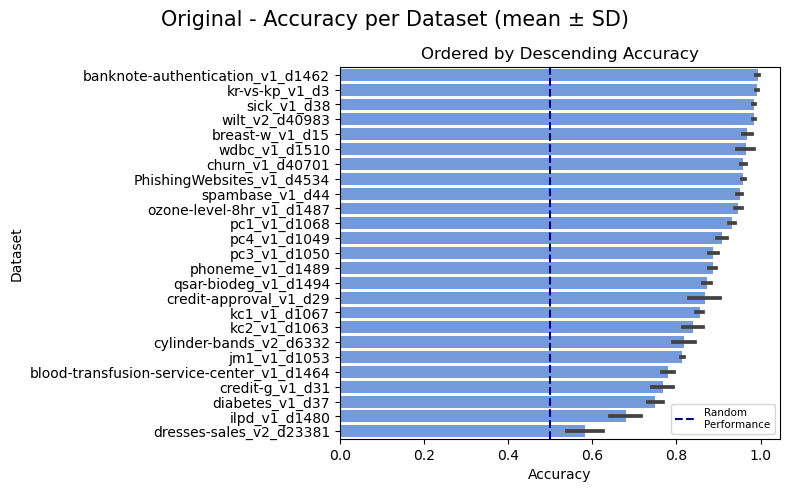

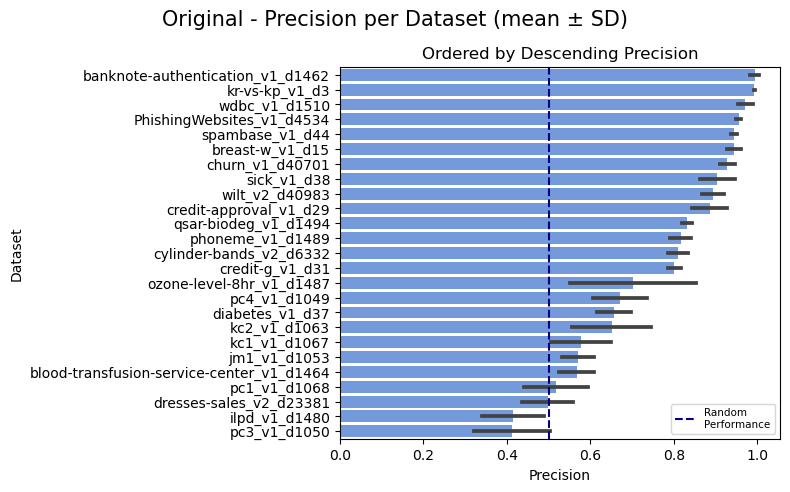

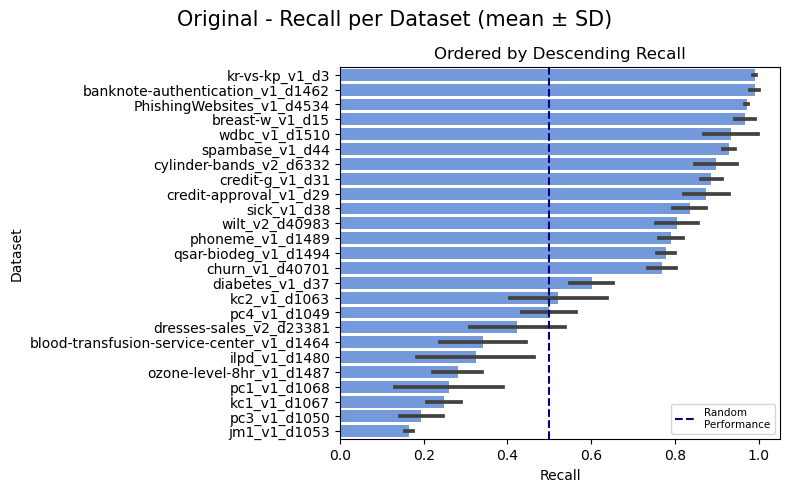

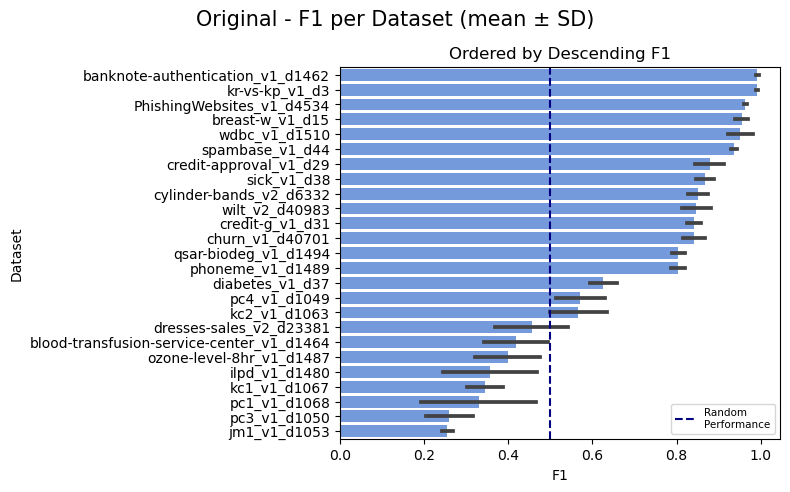

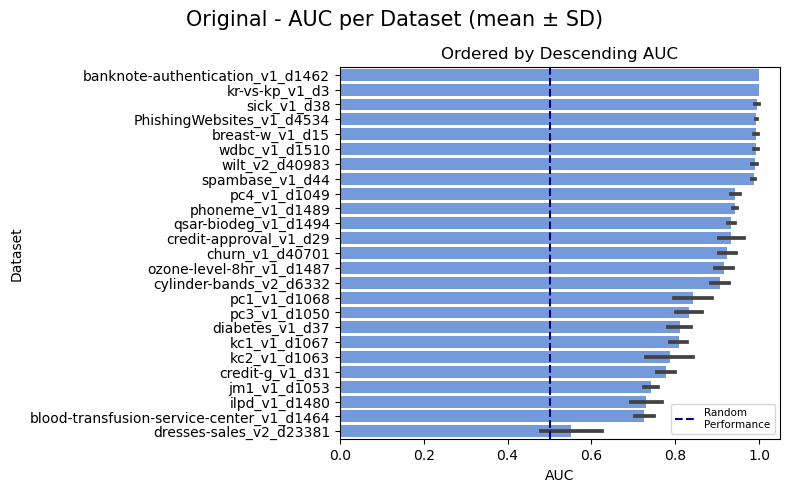

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

for metric in metrics:
    plt.figure(figsize=(8,5))
    
    # Compute mean per dataset for ordering
    dataset_order = metrics_original.groupby("Dataset")[metric].mean().sort_values(ascending=False).index
    
    sns.barplot(
        data=metrics_original,
        y="Dataset",
        x=metric,
        order=dataset_order,    # Order bars by mean value
        errorbar="sd",          # Add SD error bars
        color="cornflowerblue"
    )

    plt.axvline(x=0.5, color="navy", linestyle="--", linewidth=1.5, label="Random\nPerformance")
    plt.suptitle(f"Original - {metric} per Dataset (mean ± SD)",y=0.975, fontsize=15)
    plt.title(f"Ordered by Descending {metric}")
    plt.xlabel(metric)
    plt.ylabel("Dataset")
    plt.tight_layout()
    plt.legend(fontsize=7.5)
    plt.show()

**Accuracy:**
\
The model demonstrates generally high accuracy across most datasets, indicating that it performs well in correctly predicting the majority of instances. While accuracy is strong in general, it shows slight reductions on more challenging cases, reflecting that the model’s overall correctness is robust but not perfect. The differences between datasets are subtle, suggesting stable performance overall.

**Precision:**
\
Precision results show variability, with some values exhibiting notable improvements over baseline performance and others showing small declines. This indicates that the model’s ability to avoid false positives is strong in many cases but can be affected in more difficult conditions. Overall, precision is mostly high, reflecting reliable positive predictions.

**Recall:**
\
Recall is generally lower than precision in several datasets, indicating that the model sometimes fails to identify all true positives. This trend is most notable in datasets with more complex patterns or fewer positive instances, highlighting that sensitivity is less consistent than overall correctness.

**F1 Score:**
\
The F1 score balances the trends of precision and recall, showing moderate variability across the results. High F1 values occur when both precision and recall are relatively strong, while lower F1 values indicate cases where one metric is reduced. Overall, F1 suggests that the model maintains a reasonable balance between precision and recall, though performance can dip slightly in challenging cases.

**AUC:**
\
AUC remains consistently strong across the results, confirming that the model ranks instances effectively. Even when precision or recall show minor declines, AUC remains high, demonstrating robust discriminatory ability. This reflects that the model’s ranking performance is stable and less sensitive to fluctuations in other metrics.

**Additional Observations:**
Some datasets exhibit larger standard deviations across folds, indicating less stable performance. The descending order of datasets in the plots highlights which datasets are easier or harder for the model, providing insight into the relative challenge posed by each dataset.

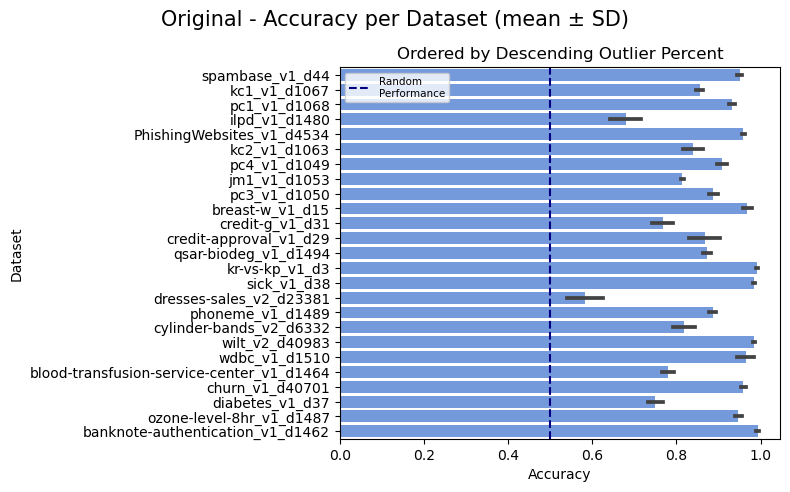

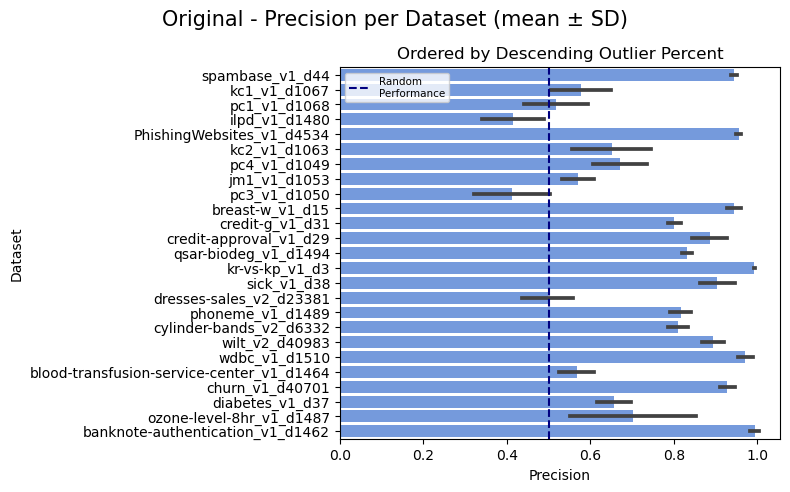

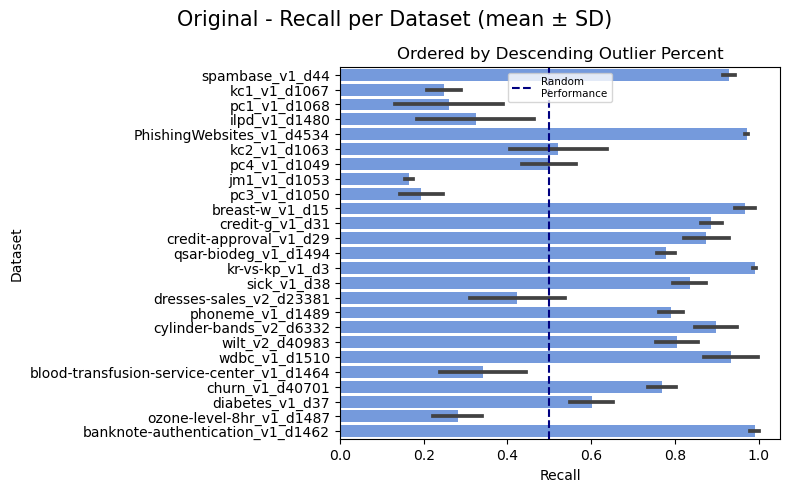

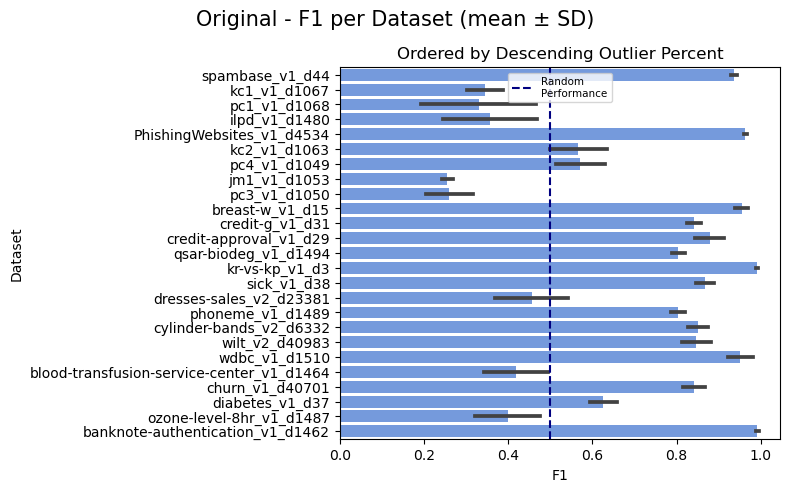

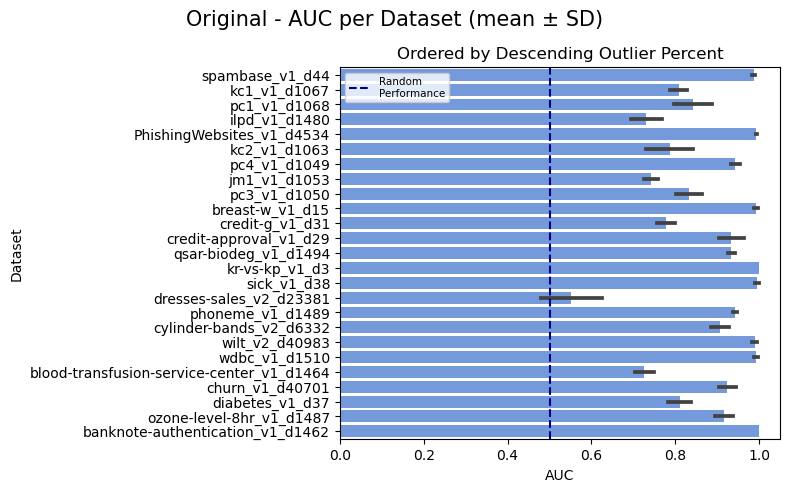

In [70]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

for metric in metrics:
    plt.figure(figsize=(8,5))
    
    analysis_df_filtered = datasets_for_experiment[~datasets_for_experiment["Dataset_Name"].isin(exclude)].copy()
    # Compute mean per dataset for ordering
    dataset_order = (
        analysis_df_filtered
        .sort_values("Outlier_Percent", ascending=False)["Dataset_Name"]
        .tolist()
    )
    
    sns.barplot(
        data=metrics_original,
        y="Dataset",
        x=metric,
        order=dataset_order,  # Order bars by mean value
        errorbar="sd",          # Add SD error bars
        color="cornflowerblue"
    )

    plt.axvline(x=0.5, color="navy", linestyle="--", linewidth=1.5, label="Random\nPerformance")
    plt.suptitle(f"Original - {metric} per Dataset (mean ± SD)",y=0.975, fontsize=15)
    plt.title(f"Ordered by Descending Outlier Percent")
    plt.xlabel(metric)
    plt.ylabel("Dataset")
    plt.legend(fontsize=7.5)
    plt.tight_layout()
    plt.show()

The bars in these plots are arranged according to the outlier percentage for each metric. Despite this ordering, **no consistent trend or correlation is apparent** between model performance and the proportion of outliers.

### Altered Model Metrics

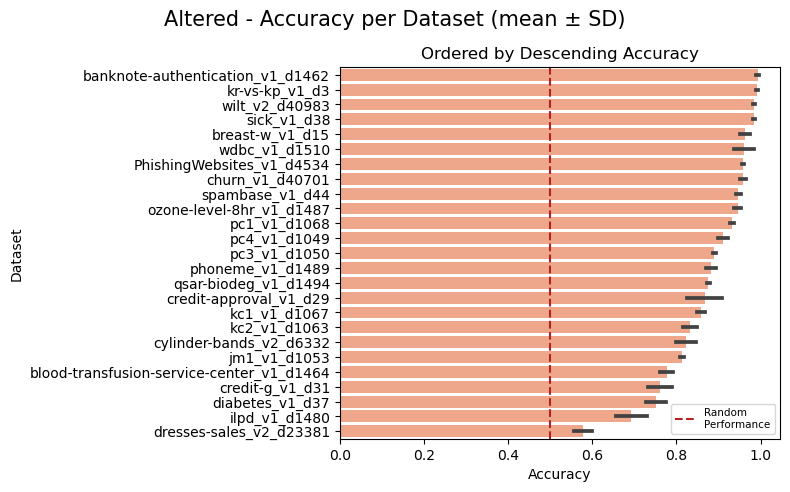

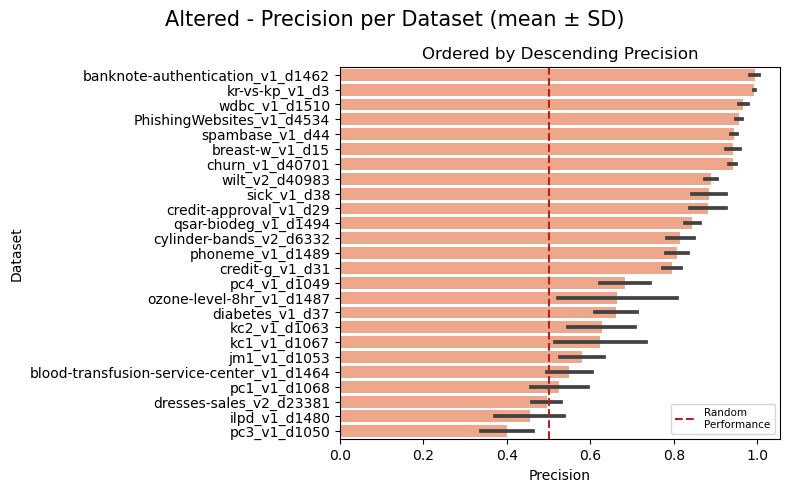

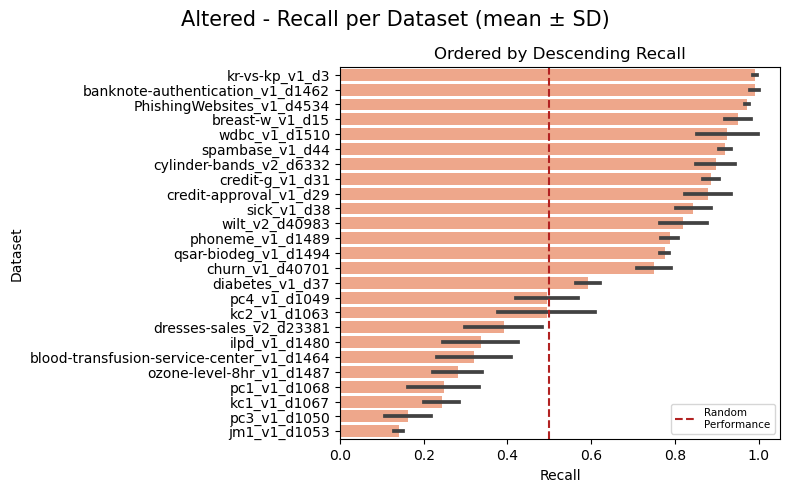

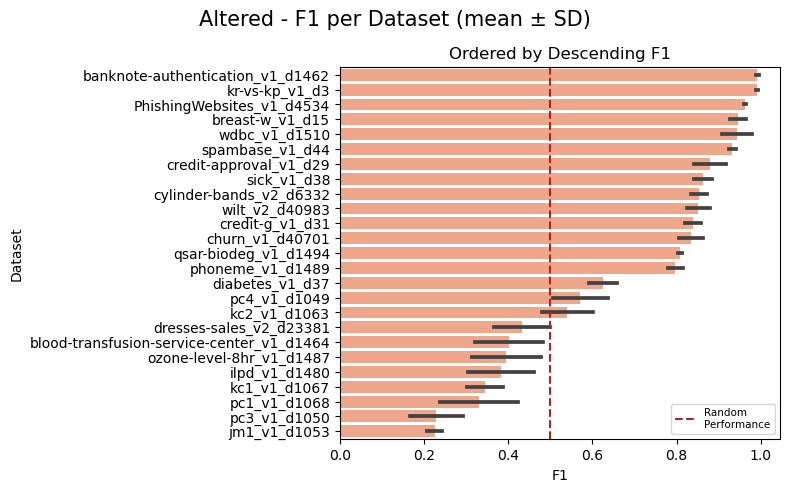

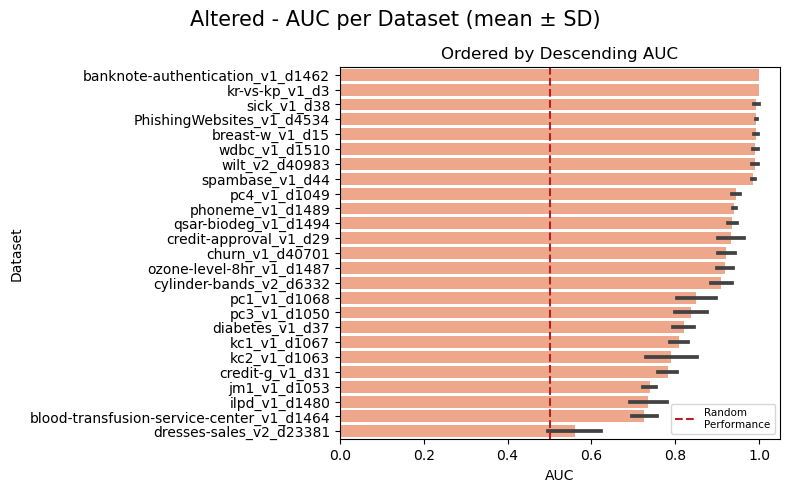

In [79]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

for metric in metrics:
    plt.figure(figsize=(8,5))
    
    # Compute mean per dataset for ordering
    dataset_order = metrics_altered.groupby("Dataset")[metric].mean().sort_values(ascending=False).index
    
    sns.barplot(
        data=metrics_altered,
        y="Dataset",
        x=metric,
        order=dataset_order,  # Order bars by mean value
        errorbar="sd",          # Add SD error bars
        color="lightsalmon"

    )

    plt.axvline(x=0.5, color="firebrick", linestyle="--", linewidth=1.5, label="Random\nPerformance")
    plt.suptitle(f"Altered - {metric} per Dataset (mean ± SD)",y=0.975, fontsize=15)
    plt.title(f"Ordered by Descending {metric}")
    plt.xlabel(metric)
    plt.ylabel("Dataset")
    plt.tight_layout()
    plt.legend(fontsize=7.5)
    plt.show()

**Accuracy:**
\
The model achieves high accuracy across the majority of results, frequently exceeding 0.9 in well-performing cases. While overall accuracy remains strong, it declines in more challenging datasets, reflecting that the model’s ability to correctly classify instances can be affected by factors such as dataset complexity or class imbalance. Despite these variations, the overall trend indicates that the model is generally robust and reliable in its predictions.

**Precision:**
\
Precision exhibits moderate variability, with many results exceeding 0.8, indicating that the model effectively minimizes false positives in most cases. In more challenging scenarios, however, precision declines, suggesting that a higher proportion of predicted positives may be incorrect. Nonetheless, precision remains relatively strong overall, demonstrating that positive predictions made by the model are typically accurate.

**Recall:**
\
Recall is generally lower than precision across the evaluated cases, with notable reductions observed in more complex datasets. This suggests that the model occasionally fails to identify all positive instances, highlighting a sensitivity limitation. The variability in recall indicates that while the model is precise in its positive predictions, it does not consistently capture every positive instance.

**F1 Score:**
\
The F1 score, which balances precision and recall, reflects moderate variability consistent with the trends observed in the other metrics. High F1 values correspond to cases where both precision and recall are strong, whereas lower F1 values occur when recall is limited. Overall, the F1 score demonstrates that the model maintains a reasonable balance between precision and recall, though performance diminishes under more challenging conditions.

**AUC:**
\
The Area Under the Curve (AUC) remains consistently high across most results, often exceeding 0.9, indicating that the model effectively ranks instances even when precision or recall is lower. This underscores the model’s strong discriminative ability, as it generally assigns higher likelihoods to positive instances than to negative ones. The stability of AUC across datasets suggests that the model’s ranking performance is robust and less sensitive to variations in other performance metrics.

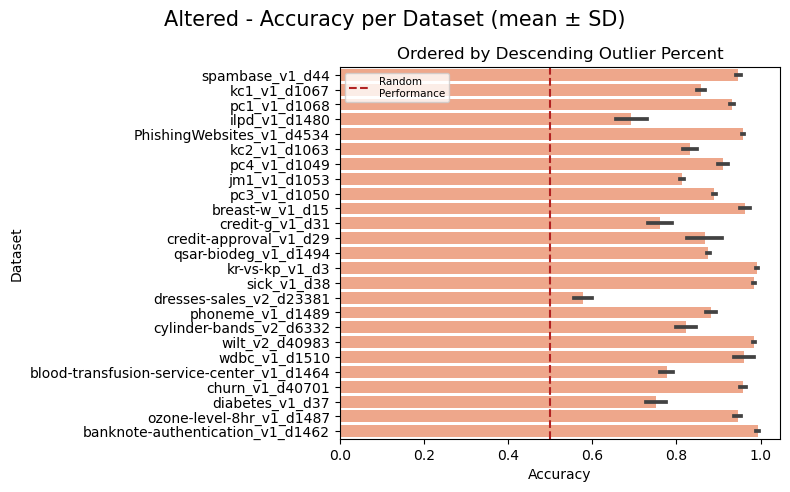

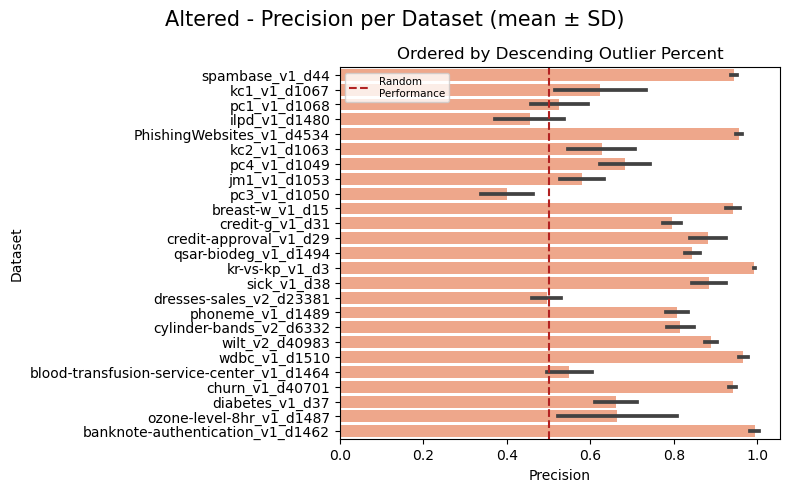

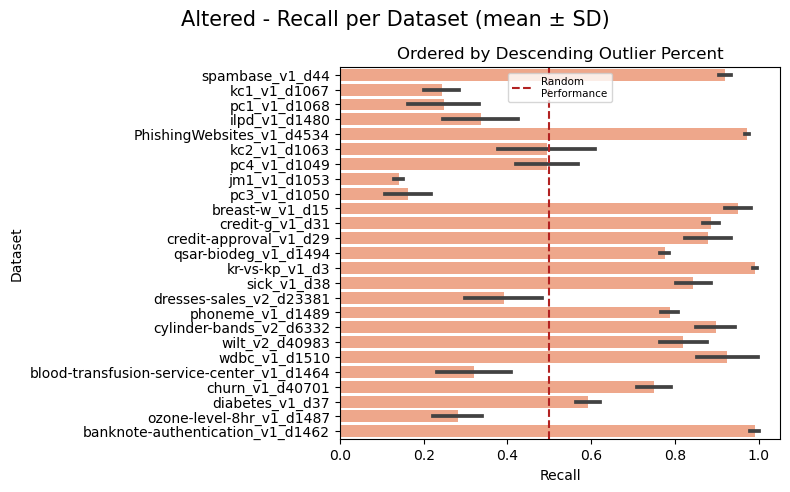

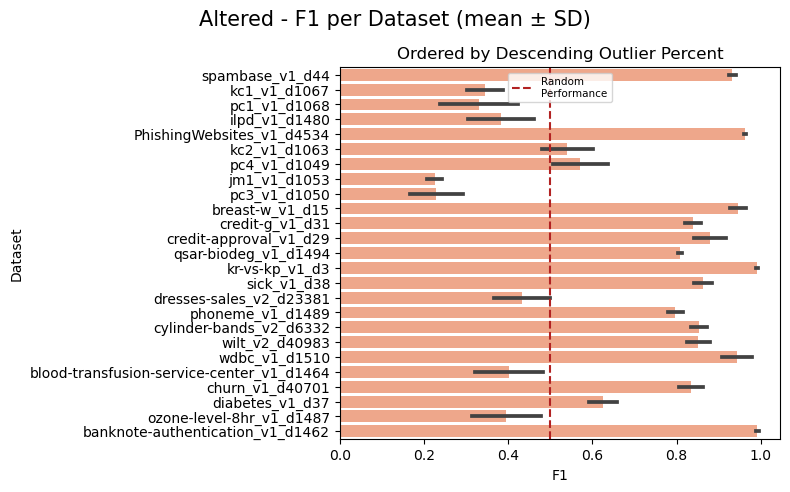

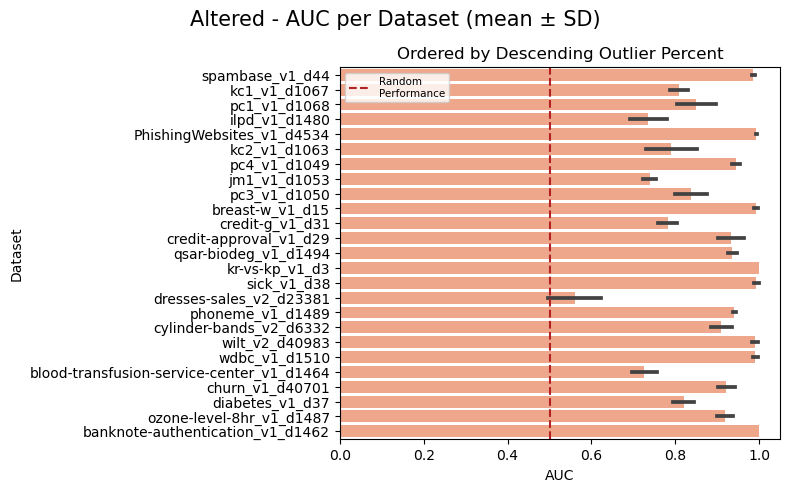

In [81]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC"]

for metric in metrics:
    plt.figure(figsize=(8,5))
    
    # Compute mean per dataset for ordering
    dataset_order = (
        analysis_df_filtered
        .sort_values("Outlier_Percent", ascending=False)["Dataset_Name"]
        .tolist()
    )
    
    sns.barplot(
        data=metrics_altered,
        y="Dataset",
        x=metric,
        order=dataset_order,  # Order bars by mean value
        errorbar="sd",          # Add SD error bars
        color="lightsalmon"

    )

    plt.axvline(x=0.5, color="firebrick", linestyle="--", linewidth=1.5, label="Random\nPerformance")
    plt.suptitle(f"Altered - {metric} per Dataset (mean ± SD)",y=0.975, fontsize=15)
    plt.title(f"Ordered by Descending Outlier Percent")
    plt.xlabel(metric)
    plt.ylabel("Dataset")
    plt.legend(fontsize=7.5)
    plt.tight_layout()
    plt.show()

The bars in these plots are arranged according to the outlier percentage for each metric. Despite this ordering, **no consistent trend or correlation is apparent** between model performance and the proportion of outliers.

## Fold-wise Differences Between Original and Altered Models

In [27]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "AUC"]
diff = metrics_altered[metric_cols] - metrics_original[metric_cols]

diff.insert(0, "Dataset", metrics_original["Dataset"])

for col in metric_cols:
    diff[col] = diff[col].apply(lambda x: f"{x:.3e}")  

print(diff.to_markdown(index=False))

| Dataset                                   |   Accuracy |   Precision |    Recall |         F1 |        AUC |
|:------------------------------------------|-----------:|------------:|----------:|-----------:|-----------:|
| banknote-authentication_v1_d1462          |  0         |   0         |  0        |  0         |  0         |
| banknote-authentication_v1_d1462          |  0         |   0         |  0        |  0         | -0.0001071 |
| banknote-authentication_v1_d1462          |  0         |   0         |  0        |  0         |  0         |
| banknote-authentication_v1_d1462          |  0         |   0         |  0        |  0         | -5.393e-05 |
| banknote-authentication_v1_d1462          |  0         |   0         |  0        |  0         |  5.393e-05 |
| blood-transfusion-service-center_v1_d1464 |  0.02667   |   0.07143   | -0.02778  |  0.01429   |  0.003289  |
| blood-transfusion-service-center_v1_d1464 | -0.01333   |  -0.04091   | -0.05556  | -0.05542   |  0.006823  |
|

## Mean Differences Between Original and Altered Models

In [28]:
diff[metric_cols] = diff[metric_cols].apply(pd.to_numeric, errors='coerce')
df_agg = diff.groupby('Dataset', as_index=False)[metric_cols].mean()
print(df_agg.to_markdown(index=False))

| Dataset                                   |    Accuracy |   Precision |     Recall |          F1 |          AUC |
|:------------------------------------------|------------:|------------:|-----------:|------------:|-------------:|
| PhishingWebsites_v1_d4534                 | -9.054e-05  |  6.62e-06   | -0.0001634 | -8.42e-05   | -0.000202262 |
| banknote-authentication_v1_d1462          |  0          |  0          |  0         |  0          | -2.142e-05   |
| blood-transfusion-service-center_v1_d1464 | -0.0026914  | -0.01721    | -0.022382  | -0.017097   | -0.0004876   |
| breast-w_v1_d15                           | -0.0057446  | -0.00093606 | -0.016582  | -0.00872    | -0.00045426  |
| churn_v1_d40701                           | -0.001      |  0.0129846  | -0.0197868 | -0.00702956 | -0.0024402   |
| credit-approval_v1_d29                    |  4e-07      | -0.0044486  |  0.005196  |  0.0006122  | -0.00046734  |
| credit-g_v1_d31                           | -0.006      | -0.0059752  

## Heatmap of Differences

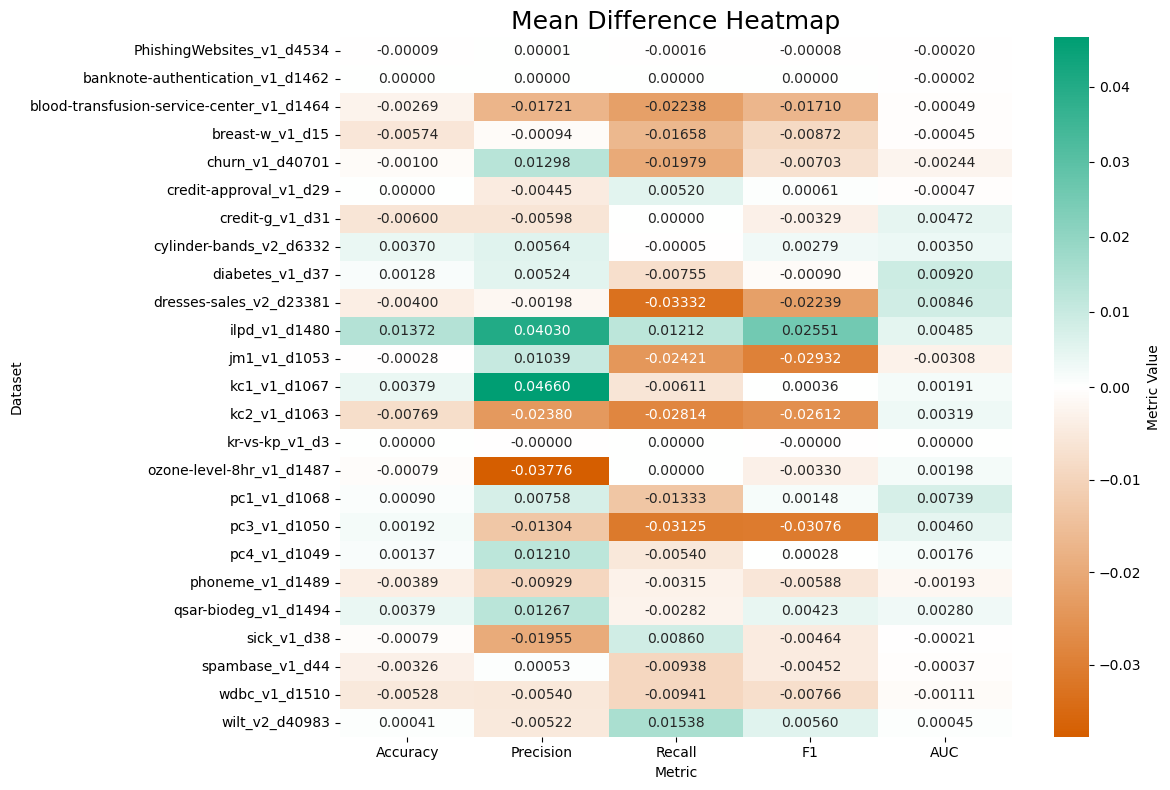

In [29]:
df_heatmap = df_agg.set_index('Dataset')

vmin = df_heatmap.min().min()
vmax = df_heatmap.max().max()

cmap = LinearSegmentedColormap.from_list("custom_rwg", ["#D55E00", "white", "#009E73"])

plt.figure(figsize=(12, 8))
sns.heatmap(
    df_heatmap,
    annot=True,
    fmt=".5f",
    cmap=cmap,
    norm=TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax),  # Center white at 0
    cbar_kws={'label': 'Metric Value'}
)
plt.title("Mean Difference Heatmap", fontsize=18)
plt.ylabel("Dataset")
plt.xlabel("Metric")
plt.tight_layout()
plt.show()

**Heatmap Analysis**

The results indicate that introducing the alteration in XGBoost led to only **minimal changes** compared to the original model. Most values are extremely close to zero (typically within the ±0.00 to ±0.01 range), which is reflected in the predominance of white and very light colors in the heatmap centered around 0.00.

The global performance metrics, **Accuracy and AUC**, show **negligible differences**, generally between 0.000 and ±0.005. This demonstrates that both the overall classification performance and the model’s discriminative ability remain virtually unchanged after applying the alteration.

Metrics that depend on a classification threshold — **Precision, Recall, and F1-score** — exhibit small fluctuations, but with a **prevailing trend of non-improvement**. The frequent presence of light orange or brown hues in these columns indicates slight negative differences, suggesting that gradient clipping produced a minor and non-significant degradation of these metrics across several datasets. 
Recall in particular shows some more notably negative values, indicating a slight reduction in model sensitivity in specific cases. There are, however, isolated improvements, such as the increase in Precision, highlighted by light green tones. 

- **Conclusion:** 

While the alterations were intended to improve model performance, the data indicate that **the altered model performs essentially the same as the original** across all evaluated metrics. The differences are negligible, showing that the alterations neither substantially improve nor degrade the model’s predictive behavior. This confirms that the original model is already robust and that the changes introduced have only minimal measurable impact.

## Additional Research: Synthetic Data Experiments

### Synthetic Datasets

In [61]:
def generate_synthetic_dataset(n_samples=750, n_features=5, outlier_fraction=0.25, random_state=42):
    """
    Generate a synthetic dataset with a given number of samples, features, 
    a fraction of outliers, and a binary target.
    
    Parameters:
    - n_samples: int, number of rows
    - n_features: int, number of features
    - outlier_fraction: float, fraction of feature entries to be outliers
    - random_state: int, seed for reproducibility
    
    Returns:
    - df: pandas DataFrame with features and a binary target
    """
    np.random.seed(random_state)
    
    # Generate normal feature data
    data = np.random.normal(loc=0, scale=1, size=(n_samples, n_features))
    
    # Inject outliers
    n_outliers = int(outlier_fraction * n_samples * n_features)
    outlier_indices = (
        np.random.randint(0, n_samples, n_outliers),
        np.random.randint(0, n_features, n_outliers)
    )
    data[outlier_indices] = np.random.choice([-1000000, 1000000], size=n_outliers)
    
    # Generate binary target
    target = np.random.randint(0, 2, size=n_samples)
    
    # Create DataFrame
    df = pd.DataFrame(data, columns=[f"Feature_{i+1}" for i in range(n_features)])
    df['Target'] = target
    
    return df

In [62]:
df_20 = generate_synthetic_dataset(n_samples=2500, n_features=10, outlier_fraction=0.20, random_state=42)
print(df_20.to_markdown(index=False))
print(f"Total entries: {df_20.shape[0]*df_20.shape[1]-1}, Outliers injected: {int(0.25 * df_20.shape[0] * (df_20.shape[1]-1))}")
print(f"Target distribution:\n{df_20['Target'].value_counts()}")

|    Feature_1 |    Feature_2 |    Feature_3 |    Feature_4 |    Feature_5 |   Feature_6 |    Feature_7 |    Feature_8 |   Feature_9 |   Feature_10 |   Target |
|-------------:|-------------:|-------------:|-------------:|-------------:|------------:|-------------:|-------------:|------------:|-------------:|---------:|
|  0.496714    | -0.138264    |  0.647689    |  1.52303     | -0.234153    | -0.234137   |  1.57921     | -1e+06       | -0.469474   |  0.54256     |        1 |
| -0.463418    | -0.46573     |  0.241962    | -1.91328     | -1.72492     | -0.562288   | -1.01283     |  0.314247    | -0.908024   | -1.4123      |        0 |
|  1.46565     | -0.225776    |  0.0675282   | -1.42475     | -0.544383    |  1e+06      | -1.15099     |  0.375698    | -0.600639   | -0.291694    |        0 |
| -0.601707    |  1.85228     | -1e+06       | -1.05771     |  0.822545    | -1.22084    |  0.208864    | -1.95967     | -1.32819    |  0.196861    |        0 |
|  0.738467    |  0.171368    | -0

In [63]:
df_30 = generate_synthetic_dataset(n_samples=2500, n_features=10, outlier_fraction=0.30, random_state=42)
print(df_30.to_markdown(index=False))
print(f"Total entries: {df_30.shape[0]*df_30.shape[1]-1}, Outliers injected: {int(0.25 * df_30.shape[0] * (df_30.shape[1]-1))}")
print(f"Target distribution:\n{df_30['Target'].value_counts()}")

|    Feature_1 |    Feature_2 |    Feature_3 |    Feature_4 |   Feature_5 |   Feature_6 |    Feature_7 |    Feature_8 |   Feature_9 |   Feature_10 |   Target |
|-------------:|-------------:|-------------:|-------------:|------------:|------------:|-------------:|-------------:|------------:|-------------:|---------:|
|  0.496714    | -0.138264    | -1e+06       |  1e+06       | -1e+06      | -0.234137   |  1.57921     |  0.767435    | -0.469474   |  1e+06       |        1 |
| -0.463418    | -0.46573     |  0.241962    | -1.91328     | -1.72492    | -0.562288   | -1.01283     |  0.314247    | -0.908024   | -1.4123      |        0 |
|  1.46565     | -0.225776    |  0.0675282   | -1.42475     | -0.544383   |  0.110923   | -1.15099     |  1e+06       | -0.600639   | -0.291694    |        1 |
| -1e+06       |  1.85228     | -0.0134972   |  1e+06       |  0.822545   | -1.22084    |  0.208864    | -1.95967     |  1e+06      |  0.196861    |        0 |
|  0.738467    |  0.171368    | -0.11564

In [64]:
df_40 = generate_synthetic_dataset(n_samples=2500, n_features=10, outlier_fraction=0.40, random_state=42)
print(df_40.to_markdown(index=False))
print(f"Total entries: {df_40.shape[0]*df_40.shape[1]-1}, Outliers injected: {int(0.25 * df_40.shape[0] * (df_40.shape[1]-1))}")
print(f"Target distribution:\n{df_40['Target'].value_counts()}")

|    Feature_1 |    Feature_2 |   Feature_3 |    Feature_4 |    Feature_5 |   Feature_6 |    Feature_7 |    Feature_8 |   Feature_9 |   Feature_10 |   Target |
|-------------:|-------------:|------------:|-------------:|-------------:|------------:|-------------:|-------------:|------------:|-------------:|---------:|
|  1e+06       | -0.138264    |  1e+06      | -1e+06       | -0.234153    | -0.234137   |  1.57921     | -1e+06       |  1e+06      |  0.54256     |        1 |
| -0.463418    | -0.46573     |  0.241962   | -1.91328     |  1e+06       | -0.562288   | -1.01283     |  0.314247    | -0.908024   | -1.4123      |        1 |
|  1.46565     | -0.225776    |  0.0675282  | -1.42475     | -1e+06       |  1e+06      | -1.15099     |  0.375698    | -0.600639   | -0.291694    |        1 |
| -0.601707    |  1.85228     | -0.0134972  | -1.05771     |  1e+06       |  1e+06      |  1e+06       | -1.95967     | -1.32819    |  0.196861    |        1 |
|  0.738467    | -1e+06       | -1e+06  

To evaluate the algorithm and assess the impact of the alteration under controlled conditions, we generated **synthetic datasets** with a **fixed number of samples and features**. 

Outliers were systematically injected into the feature matrix at **rates of 20%, 30%, and 40%**, simulating progressively more challenging data scenarios. Each dataset also included a randomly generated target variable to enable consistent performance comparison. 

This synthetic setup allowed us to examine how both the original algorithm and its altered version behave under increasing levels of extreme feature values, providing insights into their robustness and sensitivity to outliers.

### Models Training - Original and Altered

In [65]:
output_dir = "Original_Synthetic"
os.makedirs(output_dir, exist_ok=True)

In [66]:
# Parameters 
params = {
    "learning_rate": 0.1,
    "max_depth": 5,
    "subsample": 1.0,
    "reg_lambda": 1.0,
    "gamma": 0.0
}

num_boost_round= 100

In [67]:
# Training and evaluating each dataset 
results = []
k = 5

synthetic_datasets = [
    {"name": "df_20", "df": df_20},
    {"name": "df_30", "df": df_30},
    {"name": "df_40", "df": df_40}
]

for dataset in synthetic_datasets:

    print(f"Training {dataset['name']}...")
    df = dataset["df"]
    target_col = "Target"
    X = df.drop(columns=[target_col])
    y = df[target_col]

    fold_metrics = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "AUC": []
    }

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"  Fold {fold+1}/{k}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Train model on this fold
        model = XGBoostModel(params)
        model.fit(X_train, y_train, BinaryLogisticObjective(), num_boost_round)

        # Predictions
        preds = model.predict_class(X_test)
        probs = model.predict_proba(X_test)

        # Compute metrics
        fold_metrics["Accuracy"].append(accuracy_score(y_test, preds))
        fold_metrics["Precision"].append(precision_score(y_test, preds))
        fold_metrics["Recall"].append(recall_score(y_test, preds))
        fold_metrics["F1"].append(f1_score(y_test, preds))
        fold_metrics["AUC"].append(roc_auc_score(y_test, probs))


    # Convert to DataFrame after all folders are processed
    df_fold = pd.DataFrame(fold_metrics)

    # Save CSV: one file per dataset
    output_path = os.path.join(output_dir, f"results_{dataset['name']}.csv")
    df_fold.to_csv(output_path, index=False)

    # Average metrics for this dataset
    results.append({
        "Dataset": dataset['name'],
        "Accuracy": np.mean(fold_metrics["Accuracy"]),
        "Precision": np.mean(fold_metrics["Precision"]),
        "Recall": np.mean(fold_metrics["Recall"]),
        "F1": np.mean(fold_metrics["F1"]),
        "AUC": np.mean(fold_metrics["AUC"])
    })

# Results
results_df = pd.DataFrame(results)
results_df.to_csv("original_synthetic_results.csv", index=False)
print("\nFinal Results:")
print(results_df.to_markdown(index=False, floatfmt=".3f"))

Training df_20...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training df_30...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training df_40...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

Final Results:
| Dataset   |   Accuracy |   Precision |   Recall |    F1 |   AUC |
|:----------|-----------:|------------:|---------:|------:|------:|
| df_20     |      0.501 |       0.501 |    0.504 | 0.502 | 0.505 |
| df_30     |      0.498 |       0.486 |    0.466 | 0.475 | 0.488 |
| df_40     |      0.516 |       0.527 |    0.551 | 0.538 | 0.512 |


In [68]:
output_dir = "Altered_Synthetic"
os.makedirs(output_dir, exist_ok=True)

In [69]:
# Parameters 
params = {
    "learning_rate": 0.1,
    "max_depth": 5,
    "subsample": 1.0,
    "reg_lambda": 1.0,
    "gamma": 0.0,
    "grad_clip": 0.5
}
num_boost_round = 100

In [70]:
# Training and evaluating each dataset 
results_alt = []
k = 5

synthetic_datasets = [
    {"name": "df_20", "df": df_20},
    {"name": "df_30", "df": df_30},
    {"name": "df_40", "df": df_40}
]

for dataset in synthetic_datasets:

    print(f"Training {dataset['name']}...")
    df = dataset["df"]
    target_col = "Target"
    X = df.drop(columns=[target_col])
    y = df[target_col]

    fold_metrics = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "AUC": []
    }

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
        print(f"  Fold {fold+1}/{k}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Train model on this fold
        model = XGBoostModel_Alt(params)
        model.fit(X_train, y_train, BinaryLogisticObjective(), num_boost_round)

        # Predictions
        preds = model.predict_class(X_test)
        probs = model.predict_proba(X_test)

        # Compute metrics
        fold_metrics["Accuracy"].append(accuracy_score(y_test, preds))
        fold_metrics["Precision"].append(precision_score(y_test, preds))
        fold_metrics["Recall"].append(recall_score(y_test, preds))
        fold_metrics["F1"].append(f1_score(y_test, preds))
        fold_metrics["AUC"].append(roc_auc_score(y_test, probs))


    # Convert to DataFrame after all folders are processed
    df_fold = pd.DataFrame(fold_metrics)

    # Save CSV: one file per dataset
    output_path = os.path.join(output_dir, f"results_{dataset['name']}.csv")
    df_fold.to_csv(output_path, index=False)

    # Average metrics for this dataset
    results_alt.append({
        "Dataset": dataset['name'],
        "Accuracy": np.mean(fold_metrics["Accuracy"]),
        "Precision": np.mean(fold_metrics["Precision"]),
        "Recall": np.mean(fold_metrics["Recall"]),
        "F1": np.mean(fold_metrics["F1"]),
        "AUC": np.mean(fold_metrics["AUC"])
    })

# Results
results_alt_df = pd.DataFrame(results_alt)
results_alt_df.to_csv("altered_synthetic_results.csv", index=False)
print("\nFinal Results:")
print(results_alt_df.to_markdown(index=False, floatfmt=".3f"))

Training df_20...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training df_30...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5
Training df_40...
  Fold 1/5
  Fold 2/5
  Fold 3/5
  Fold 4/5
  Fold 5/5

Final Results:
| Dataset   |   Accuracy |   Precision |   Recall |    F1 |   AUC |
|:----------|-----------:|------------:|---------:|------:|------:|
| df_20     |      0.500 |       0.500 |    0.490 | 0.495 | 0.511 |
| df_30     |      0.497 |       0.483 |    0.444 | 0.462 | 0.492 |
| df_40     |      0.504 |       0.516 |    0.532 | 0.524 | 0.504 |


##  Metrics Tables

In [98]:
results_df = pd.read_csv("original_synthetic_results.csv")
print("Original Model Metrics")
print("-------------------------------------------------------------------")
print(results_df.to_markdown(index=False, floatfmt=".3f"))
print("-------------------------------------------------------------------")
print("\nAltered Model Metrics")
print("-------------------------------------------------------------------")
results_alt_df = pd.read_csv("altered_synthetic_results.csv")
print(results_alt_df.to_markdown(index=False, floatfmt=".3f"))
print("-------------------------------------------------------------------")


Original Model Metrics
-------------------------------------------------------------------
| Dataset   |   Accuracy |   Precision |   Recall |    F1 |   AUC |
|:----------|-----------:|------------:|---------:|------:|------:|
| df_20     |      0.501 |       0.501 |    0.504 | 0.502 | 0.505 |
| df_30     |      0.498 |       0.486 |    0.466 | 0.475 | 0.488 |
| df_40     |      0.516 |       0.527 |    0.551 | 0.538 | 0.512 |
-------------------------------------------------------------------

Altered Model Metrics
-------------------------------------------------------------------
| Dataset   |   Accuracy |   Precision |   Recall |    F1 |   AUC |
|:----------|-----------:|------------:|---------:|------:|------:|
| df_20     |      0.500 |       0.500 |    0.490 | 0.495 | 0.511 |
| df_30     |      0.497 |       0.483 |    0.444 | 0.462 | 0.492 |
| df_40     |      0.504 |       0.516 |    0.532 | 0.524 | 0.504 |
-------------------------------------------------------------------


**Analysis of Original and Altered XGBoost Models on Synthetic Datasets**

Across all three synthetic datasets, the **performance metrics** for both the original and altered models remain **close to 0.5**, which is consistent with random-guessing behaviour and reflects the absence of any learnable structure in the data. The small variations observed in Accuracy, Precision, Recall, F1, and AUC fall within the range expected from noise and d**o not indicate any substantive performance shift**.

The intention was to examine whether the alteration could offer improved robustness under increasingly extreme outlier conditions. However, the comparison between the two models shows **no consistent pattern of improvement or deterioration**. The observed differences are minimal and unsystematic, suggesting that the modification does not meaningfully influence model behaviour when the data contain no signal to exploit.

Although the alteration did not yield measurable benefits in this controlled setting, the experiment still provides valuable insight: in environments dominated by randomness, neither the baseline algorithm nor its modified version can outperform chance-level prediction, and the modification remains neutral rather than destabilising. This helps contextualise the alteration’s effects and guides further investigation using datasets with genuine structure or domain-specific patterns.